# Singapore Tourism Arrivals — Week 3: Uncertainty Quantification

**Goal:** Move beyond point forecasts — attach calibrated prediction intervals to every model  
**New concept:** Conformal prediction — a 3-line wrapper that gives distribution-free coverage guarantees on *any* model  
**Evaluation:** Same validation window (2019), but now measuring interval *coverage* and *width* alongside MAE/RMSE

---

## Data Decisions Log (Week 3)

| Decision | Rationale |
|---|---|
| New calibration split: 2017–2018 | Conformal prediction requires held-out residuals — using in-sample residuals inflates stated coverage and voids the guarantee |
| Models refit on ≤ 2016 | Ensures calibration set is truly unseen; point estimates are slightly weaker than W1/W2 — an honest tradeoff |
| Conformal scores computed in log space | Models predict log(arrivals); symmetric bands in log space → asymmetric in original scale, which respects positivity and matches the data's multiplicative nature |
| Finite-sample quantile correction | `ceil((n+1)(1-α)/n)` not `(1-α)` — critical when n=24; guarantees marginal coverage even for small calibration sets |
| NeuralProphet: drop NaN cal rows | n_lags=12 means the first 12 calibration months have no AR context; we use the 12 available residuals rather than impute |
| Report both coverage AND width | A trivially wide interval always achieves 100% coverage — width is the informativeness penalty |

---

## 0. Setup & Dependencies

In [2]:
# Install Week 3 dependencies (run once — same stack as W1/W2 plus no new packages)
#!pip install pmdarima prophet neuralprophet pandas numpy matplotlib seaborn scikit-learn

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm

import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet

from neuralprophet import NeuralProphet

# Consistent aesthetics across all weeks
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_DIR = Path('data')
SEED = 42
ALPHA = 0.05   # target miscoverage — we want 95% intervals throughout

print('Libraries loaded ✓')

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


Libraries loaded ✓


---
## 1. Load Data & Define Splits

Week 3 introduces a **calibration split** that didn't exist in W1/W2.
Conformal prediction requires residuals on data the model has never seen;
if we calibrate on in-sample data, the model has already overfitted those points
and the residuals will be artificially small — the intervals will be too narrow.

| Split | Period | Purpose |
|---|---|---|
| `train_cp` | ≤ 2016-12 | Fit all models (shorter than W1/W2 train) |
| `cal` | 2017-01 → 2018-12 | Conformal calibration — compute non-conformity scores |
| `val` | 2019 | Evaluate intervals (same window as W1/W2) |
| `test` | ≥ 2022-01 | Locked until Week 4 |

> **Honest tradeoff:** fitting on ≤2016 instead of ≤2018 means point forecasts will be slightly weaker.
> That is the correct cost of having a genuine held-out calibration set.

In [4]:
clean_path = DATA_DIR / 'arrivals_clean.csv'
assert clean_path.exists(), "Run the Week 1 notebook first to generate arrivals_clean.csv"

df = pd.read_csv(clean_path, parse_dates=['date'])

# Same focus country selection as Week 1 & 2
FOCUS_COUNTRY = (
    df[df['date'] < '2020-01-01']
    .groupby('country')['arrivals']
    .sum()
    .idxmax()
)
print(f"Focus country: {FOCUS_COUNTRY}")

ts = (
    df[df['country'] == FOCUS_COUNTRY]
    .sort_values('date')
    .reset_index(drop=True)
    .copy()
)
ts['log_arrivals'] = np.log1p(ts['arrivals'])

# ── Week 3 splits ─────────────────────────────────────────────────────────
train_cp = ts[ts['date'] <= '2016-12-31'].copy()   # conformal training
cal      = ts[(ts['date'] >= '2017-01-01') & (ts['date'] <= '2018-12-31')].copy()
val      = ts[(ts['date'] >= '2019-01-01') & (ts['date'] <= '2019-12-31')].copy()
test     = ts[ts['date'] >= '2022-01-01'].copy()   # LOCKED

n_cal = len(cal)
n_val = len(val)

# Actuals in original scale — used for all coverage calculations
val_y_orig = np.expm1(val['log_arrivals'].values)
val_dates  = val['date'].values

print(f"\ntrain_cp : {len(train_cp):3d} rows  ({train_cp['date'].min().date()} → {train_cp['date'].max().date()})")
print(f"cal      : {n_cal:3d} rows  ({cal['date'].min().date()}  → {cal['date'].max().date()})")
print(f"val      : {n_val:3d} rows  ({val['date'].min().date()}  → {val['date'].max().date()})")
print(f"test     : {len(test):3d} rows  ({test['date'].min().date()} → {test['date'].max().date()})  [LOCKED]")

Focus country: Greater China

train_cp : 108 rows  (2008-01-01 → 2016-12-01)
cal      :  24 rows  (2017-01-01  → 2018-12-01)
val      :  12 rows  (2019-01-01  → 2019-12-01)
test     :  49 rows  (2022-01-01 → 2026-01-01)  [LOCKED]


---
## 2. Refit All Four Models on `train_cp`

Each model is refit on ≤ 2016 so that 2017–2018 is genuinely held out for calibration.
We then predict across both `cal` + `val` in one forward pass.

In [5]:
# ── 2a. ARIMA (non-seasonal) ───────────────────────────────────────────────

arima_model = pm.auto_arima(
    train_cp['log_arrivals'],
    seasonal=False,
    information_criterion='aic',
    max_p=5, max_q=5, max_d=2,
    stepwise=True,
    suppress_warnings=True,
    random_state=SEED,
)
print(f"ARIMA order: {arima_model.order}")

ARIMA order: (4, 1, 2)


In [6]:
# ── 2b. SARIMA (seasonal) ─────────────────────────────────────────────────

sarima_model = pm.auto_arima(
    train_cp['log_arrivals'],
    seasonal=True, m=12,
    information_criterion='aic',
    max_p=3, max_q=3, max_d=2,
    max_P=2, max_Q=2, max_D=1,
    stepwise=True,
    suppress_warnings=True,
    random_state=SEED,
)
print(f"SARIMA order: {sarima_model.order}  seasonal: {sarima_model.seasonal_order}")

SARIMA order: (0, 1, 1)  seasonal: (1, 0, 2, 12)


In [7]:
# ── 2c. Prophet ───────────────────────────────────────────────────────────
# No COVID holiday needed here — our eval window (2017–2019) predates COVID.

def to_prophet_df(subset, log_col='log_arrivals'):
    return subset[['date', log_col]].rename(columns={'date': 'ds', log_col: 'y'})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    interval_width=1 - ALPHA,   # 0.95
)
prophet_model.fit(to_prophet_df(train_cp))
print("Prophet fitted ✓")

15:13:30 - cmdstanpy - INFO - Chain [1] start processing
15:13:30 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted ✓


In [8]:
# ── 2d. NeuralProphet ─────────────────────────────────────────────────────
# quantiles=[0.025, 0.975] enables quantile regression, giving us native
# lower/upper bounds directly from the neural network's loss function.

np_model = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_lags=12,
    n_forecasts=1,
    quantiles=[ALPHA / 2, 1 - ALPHA / 2],   # [0.025, 0.975]
    epochs=100,
    learning_rate=0.01,
)

train_np_df = to_prophet_df(train_cp)
np_model.fit(train_np_df, freq='MS')
print("NeuralProphet fitted ✓")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.074]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 8


Training: 0it [00:00, ?it/s]

NeuralProphet fitted ✓


---
## 3. Native Prediction Intervals

Each model has a built-in mechanism for producing uncertainty estimates:

| Model | Native interval source | Assumption baked in |
|---|---|---|
| ARIMA | Analytical formula from model variance | Gaussian residuals |
| SARIMA | Same as ARIMA | Gaussian residuals |
| Prophet | Posterior sampling (MCMC or variational) | Prior + likelihood specifications |
| NeuralProphet | Quantile regression (pinball loss) | Correct in expectation, not finite-sample |

We will measure whether those stated assumptions hold on our actual data.

In [9]:
# ── 3a. ARIMA & SARIMA native intervals ───────────────────────────────────
# pmdarima.predict() does NOT mutate the model's internal state,
# so we can request n_cal + n_val steps in one call and split the result.

def arima_native_preds(model, n_cal, n_val, alpha=0.05):
    """Return calibration and validation predictions + CI from a pmdarima model."""
    preds_all, ci_all = model.predict(
        n_periods=n_cal + n_val,
        return_conf_int=True,
        alpha=alpha
    )
    return {
        'cal_preds_log'  : preds_all[:n_cal],
        'val_preds_log'  : preds_all[n_cal:],
        'val_ci_log'     : ci_all[n_cal:],          # shape (n_val, 2)
        'cal_preds_orig' : np.expm1(preds_all[:n_cal]),
        'val_preds_orig' : np.expm1(preds_all[n_cal:]),
        'val_lower_orig' : np.expm1(ci_all[n_cal:, 0]),
        'val_upper_orig' : np.expm1(ci_all[n_cal:, 1]),
    }

arima_res  = arima_native_preds(arima_model,  n_cal, n_val)
sarima_res = arima_native_preds(sarima_model, n_cal, n_val)

# Calibration residuals in log space (needed for conformal later)
arima_cal_scores  = np.abs(cal['log_arrivals'].values - arima_res['cal_preds_log'])
sarima_cal_scores = np.abs(cal['log_arrivals'].values - sarima_res['cal_preds_log'])

print(f"ARIMA  — cal MAE (log): {arima_cal_scores.mean():.4f}   "
      f"val MAE (orig): {mean_absolute_error(val_y_orig, arima_res['val_preds_orig']):,.0f}")
print(f"SARIMA — cal MAE (log): {sarima_cal_scores.mean():.4f}   "
      f"val MAE (orig): {mean_absolute_error(val_y_orig, sarima_res['val_preds_orig']):,.0f}")

ARIMA  — cal MAE (log): 0.1288   val MAE (orig): 35,051
SARIMA — cal MAE (log): 0.0543   val MAE (orig): 22,269


In [10]:
# ── 3b. Prophet native intervals ──────────────────────────────────────────
# Prophet outputs yhat_lower and yhat_upper directly in its predict() result.

# Build a future frame covering cal + val
all_future_dates = pd.DataFrame({
    'ds': pd.date_range(start=cal['date'].min(), end=val['date'].max(), freq='MS')
})
prophet_forecast = prophet_model.predict(all_future_dates)

# Slice to cal and val
cal_dates_set = set(cal['date'])
val_dates_set = set(val['date'])

prophet_cal_fc = prophet_forecast[prophet_forecast['ds'].isin(cal_dates_set)].reset_index(drop=True)
prophet_val_fc = prophet_forecast[prophet_forecast['ds'].isin(val_dates_set)].reset_index(drop=True)

prophet_cal_scores  = np.abs(cal['log_arrivals'].values - prophet_cal_fc['yhat'].values)
prophet_val_preds_log = prophet_val_fc['yhat'].values

prophet_res = {
    'val_preds_log'  : prophet_val_preds_log,
    'val_preds_orig' : np.expm1(prophet_val_preds_log),
    'val_lower_orig' : np.expm1(prophet_val_fc['yhat_lower'].values),
    'val_upper_orig' : np.expm1(prophet_val_fc['yhat_upper'].values),
}

print(f"Prophet — cal MAE (log): {prophet_cal_scores.mean():.4f}   "
      f"val MAE (orig): {mean_absolute_error(val_y_orig, prophet_res['val_preds_orig']):,.0f}")

Prophet — cal MAE (log): 0.1432   val MAE (orig): 148,874


In [17]:
# ── 3c. NeuralProphet uncertainty quantification ──────────────────────────
# Root cause: NeuralProphet sets periods = n_forecasts internally, so
# make_future_dataframe with n_forecasts=1 always produces exactly 1 future
# row regardless of what you pass for periods.
#
# Fix: refit with n_forecasts = n_cal + n_val = 36.
# From the last training anchor (2016-12):
#   yhat1  = prediction for 2017-01  (cal month 1)
#   yhat24 = prediction for 2018-12  (cal month 24)
#   yhat25 = prediction for 2019-01  (val month 1)
#   yhat36 = prediction for 2019-12  (val month 12)
# All extracted from one anchor row — no rolling calls needed.

N_HORIZON = n_cal + n_val   # 36

np_model_uq = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_lags=12,
    n_forecasts=N_HORIZON,          # ← the actual fix
    quantiles=[ALPHA / 2, 1 - ALPHA / 2],
    epochs=100,
    learning_rate=0.01,
)
np_model_uq.fit(train_np_df, freq='MS')

# n_historic_predictions=True puts the 2016-12 anchor row in the output
future_uq = np_model_uq.make_future_dataframe(
    train_np_df, n_historic_predictions=True
)
fc_uq = np_model_uq.predict(future_uq)

# ── Timezone-safe date normalization ──────────────────────────────────────
def normalize_dates(s):
    s = pd.to_datetime(s)
    if hasattr(s, 'dt'):
        if s.dt.tz is not None:
            s = s.dt.tz_localize(None)
        return s.dt.normalize()
    idx = pd.DatetimeIndex(s)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    return idx.normalize()

fc_uq = fc_uq.copy()
fc_uq['_ds_norm'] = normalize_dates(fc_uq['ds'])
anchor_norm = normalize_dates(train_np_df['ds'].tail(1).values)[0]

anchor_rows = fc_uq[fc_uq['_ds_norm'] == anchor_norm]
if len(anchor_rows) == 0:
    raise RuntimeError(
        f"Anchor row not found.\n"
        f"Expected: {anchor_norm}\n"
        f"Got range: {fc_uq['_ds_norm'].min()} → {fc_uq['_ds_norm'].max()}"
    )
anchor = anchor_rows.iloc[0]

# ── Extract cal and val predictions from the anchor row ───────────────────
cal_yhat_cols = [f'yhat{i}' for i in range(1, n_cal + 1)]
val_yhat_cols = [f'yhat{i}' for i in range(n_cal + 1, N_HORIZON + 1)]

np_cal_preds_log = anchor[cal_yhat_cols].values.astype(float)
np_val_preds_log = anchor[val_yhat_cols].values.astype(float)
np_cal_scores    = np.abs(cal['log_arrivals'].values - np_cal_preds_log)

# ── Native quantile bounds ────────────────────────────────────────────────
q_low_sfx  = f'{ALPHA / 2 * 100:.1f}%'        # '2.5%'
q_high_sfx = f'{(1 - ALPHA / 2) * 100:.1f}%'  # '97.5%'

val_q_low_cols  = [f'yhat{i} {q_low_sfx}'  for i in range(n_cal + 1, N_HORIZON + 1)]
val_q_high_cols = [f'yhat{i} {q_high_sfx}' for i in range(n_cal + 1, N_HORIZON + 1)]
has_quant = all(c in fc_uq.columns for c in val_q_low_cols[:1])

if not has_quant:
    sample_q = [c for c in fc_uq.columns if '%' in c][:4]
    print(f"Quantile cols not found with expected names. Sample: {sample_q}")

np_res = {
    'val_preds_log'  : np_val_preds_log,
    'val_preds_orig' : np.expm1(np_val_preds_log),
    'val_lower_orig' : np.expm1(anchor[val_q_low_cols].values.astype(float))  if has_quant else None,
    'val_upper_orig' : np.expm1(anchor[val_q_high_cols].values.astype(float)) if has_quant else None,
    'has_native_ci'  : has_quant,
}

print(f"NeuralProphet — cal scores      : {len(np_cal_scores)} / {n_cal} months")
print(f"NeuralProphet — cal MAE (log)   : {np_cal_scores.mean():.4f}")
print(f"NeuralProphet — val MAE (orig)  : {mean_absolute_error(val_y_orig, np_res['val_preds_orig']):,.0f}")
print(f"Native quantile CI available    : {has_quant}")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.074]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 8


Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.074]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.306]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.306]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.data.processing._handle_missing_data) - Dropped 36 rows at the end with NaNs in 'y' column.


Predicting: 8it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


NeuralProphet — cal scores      : 24 / 24 months
NeuralProphet — cal MAE (log)   : 0.2924
NeuralProphet — val MAE (orig)  : 135,271
Native quantile CI available    : True


---
## 4. Conformal Prediction — A Model-Agnostic Uncertainty Layer

### Why native intervals often fail

- **ARIMA/SARIMA**: intervals assume Gaussian residuals. If your residuals are heavy-tailed or skewed, stated 95% coverage can be 70% in practice.
- **Prophet**: intervals come from posterior sampling — correct under the prior + likelihood, but real tourism data is non-stationary and the priors are generic.
- **NeuralProphet quantiles**: trained to be correct *on average* across the training distribution. With only 12 validation months, empirical coverage can swing wildly.

### What conformal prediction gives you

1. **Distribution-free**: zero assumptions about the shape of residuals.
2. **Finite-sample guarantee**: with $n$ calibration points, marginal coverage $\geq 1 - \alpha$ holds exactly — not asymptotically.
3. **Model-agnostic**: wraps any existing model in a handful of numpy lines.

### The algorithm (split conformal)

$$
\text{1. Fit } \hat{f} \text{ on training data.}
$$

$$
\text{2. Compute non-conformity scores: } s_i = |y_i - \hat{f}(X_i)| \quad \text{for } i \in \text{calibration set}
$$

$$
\text{3. } \hat{q} = \text{Quantile}\!\left(\{s_i\},\; \frac{\lceil(n+1)(1-\alpha)\rceil}{n}\right)
$$

$$
\text{4. Prediction interval for new point: } \hat{C}(X) = [\hat{f}(X) - \hat{q},\; \hat{f}(X) + \hat{q}]
$$

**Cost**: intervals are symmetric and the same width for every forecast horizon. Model-native intervals can be tighter at near horizons if the model's own uncertainty estimate is well-calibrated — but as we'll see, they often aren't.

In [18]:
# ── 4a. Conformal helper functions ────────────────────────────────────────

def split_conformal(
    cal_scores: np.ndarray,
    val_preds_log: np.ndarray,
    alpha: float = 0.05,
) -> dict:
    """
    Split conformal prediction intervals.

    Parameters
    ----------
    cal_scores : 1-D array
        Non-conformity scores on calibration set:
        s_i = |y_i - ŷ_i|  computed in **log space**.
    val_preds_log : 1-D array
        Point forecasts on validation set, in log space.
    alpha : float
        Miscoverage level (0.05 → nominal 95% coverage).

    Returns
    -------
    dict with keys:
        lower_orig, upper_orig — bounds in original (arrivals) scale
        q_hat                  — the conformal quantile (log scale)
        n_cal                  — number of calibration points used

    Notes
    -----
    Coverage guarantee: P(Y ∈ Ĉ(X)) ≥ 1 - α
    This is marginal (not conditional), distribution-free, and holds for
    ANY model as long as calibration and test data are exchangeable.
    """
    n = len(cal_scores)
    # Finite-sample corrected level — NOT simply (1-alpha).
    # The ceiling ensures the guarantee holds even for small n.
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    q_hat   = np.quantile(cal_scores, q_level)

    lower_log  = val_preds_log - q_hat
    upper_log  = val_preds_log + q_hat

    return {
        'lower_orig' : np.expm1(lower_log),
        'upper_orig' : np.expm1(upper_log),
        'q_hat'      : q_hat,
        'n_cal'      : n,
        'q_level'    : q_level,
    }


def interval_metrics(
    y_true_orig: np.ndarray,
    lower_orig: np.ndarray,
    upper_orig: np.ndarray,
) -> dict:
    """
    Compute empirical coverage and average interval width.

    Parameters
    ----------
    y_true_orig : actual arrivals
    lower_orig, upper_orig : interval bounds in original scale

    Returns
    -------
    dict with coverage (float), avg_width (float), inside (bool array)
    """
    inside   = (y_true_orig >= lower_orig) & (y_true_orig <= upper_orig)
    coverage = inside.mean()
    avg_width = (upper_orig - lower_orig).mean()
    return {
        'coverage'  : coverage,
        'avg_width' : avg_width,
        'inside'    : inside,
    }


print("Conformal helper functions defined ✓")

Conformal helper functions defined ✓


In [19]:
# ── 4b. Apply conformal to all four models ────────────────────────────────

arima_cp  = split_conformal(arima_cal_scores,   arima_res['val_preds_log'],  alpha=ALPHA)
sarima_cp = split_conformal(sarima_cal_scores,  sarima_res['val_preds_log'], alpha=ALPHA)
prophet_cp = split_conformal(prophet_cal_scores, prophet_res['val_preds_log'], alpha=ALPHA)
np_cp      = split_conformal(np_cal_scores,      np_res['val_preds_log'],     alpha=ALPHA)

print(f"{'Model':15s}  {'q̂ (log scale)':>14s}  {'Cal points used':>16s}  {'q-level':>8s}")
print("-" * 60)
for name, cp in [('ARIMA', arima_cp), ('SARIMA', sarima_cp),
                 ('Prophet', prophet_cp), ('NeuralProphet', np_cp)]:
    print(f"{name:15s}  {cp['q_hat']:>14.4f}  {cp['n_cal']:>16d}  {cp['q_level']:>8.4f}")

Model            q̂ (log scale)   Cal points used   q-level
------------------------------------------------------------
ARIMA                    0.2856                24    1.0000
SARIMA                   0.1882                24    1.0000
Prophet                  0.3170                24    1.0000
NeuralProphet            0.9003                24    1.0000


---
## 5. Coverage Evaluation

For a nominal 95% interval, we want empirical coverage ≈ 0.95 **and** intervals that are as narrow as possible.

- **Under-coverage** (< 0.95): the interval is too optimistic — it misses actual values more often than stated.
- **Over-coverage** (> 0.95): the interval is too conservative — technically correct but uninformative.
- **Width**: a trivially wide interval achieves 100% coverage. Width is the informativeness penalty.

In [20]:
# ── Build coverage summary table ──────────────────────────────────────────

rows = []

model_specs = [
    ('ARIMA',         arima_res,   arima_cp),
    ('SARIMA',        sarima_res,  sarima_cp),
    ('Prophet',       prophet_res, prophet_cp),
    ('NeuralProphet', np_res,      np_cp),
]

for name, res, cp in model_specs:
    # Native interval (skip NeuralProphet if quantile regression failed)
    if res.get('has_native_ci', True) and res['val_lower_orig'] is not None:
        nat = interval_metrics(val_y_orig, res['val_lower_orig'], res['val_upper_orig'])
        rows.append({
            'model'     : name,
            'interval'  : 'Native',
            'coverage'  : nat['coverage'],
            'avg_width' : nat['avg_width'],
            'val_mae'   : mean_absolute_error(val_y_orig, res['val_preds_orig']),
        })

    # Conformal interval
    conf = interval_metrics(val_y_orig, cp['lower_orig'], cp['upper_orig'])
    rows.append({
        'model'     : name,
        'interval'  : 'Conformal',
        'coverage'  : conf['coverage'],
        'avg_width' : conf['avg_width'],
        'val_mae'   : mean_absolute_error(val_y_orig, res['val_preds_orig']),
    })

results_df = pd.DataFrame(rows)

# Pretty-print
print(f"Nominal coverage target: {1 - ALPHA:.0%}\n")
print(f"{'Model':15s}  {'Type':10s}  {'Coverage':>9s}  {'Status':>7s}  {'Avg Width':>12s}  {'Val MAE':>10s}")
print("-" * 72)
for _, row in results_df.iterrows():
    ok = '✓' if abs(row['coverage'] - (1 - ALPHA)) <= 0.10 else '✗'
    print(f"{row['model']:15s}  {row['interval']:10s}  "
          f"{row['coverage']:>9.1%}  {ok:>7s}  "
          f"{row['avg_width']:>12,.0f}  {row['val_mae']:>10,.0f}")

Nominal coverage target: 95%

Model            Type         Coverage   Status     Avg Width     Val MAE
------------------------------------------------------------------------
ARIMA            Native         100.0%        ✓       726,798      35,051
ARIMA            Conformal      100.0%        ✓       213,888      35,051
SARIMA           Native         100.0%        ✓       700,439      22,269
SARIMA           Conformal      100.0%        ✓       151,760      22,269
Prophet          Native         100.0%        ✓       584,927     148,874
Prophet          Conformal       41.7%        ✗       341,576     148,874
NeuralProphet    Native           0.0%        ✗       101,138     135,271
NeuralProphet    Conformal      100.0%        ✓       504,646     135,271


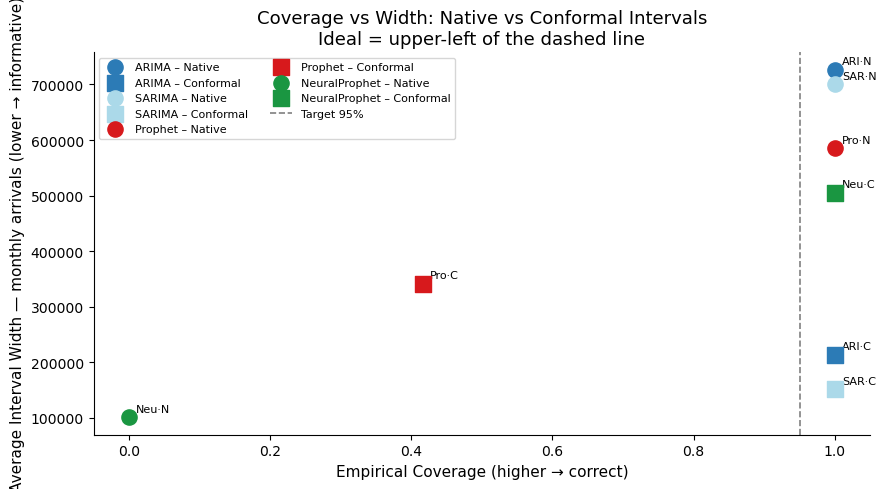

Saved: data/coverage_vs_width.png


In [21]:
# ── Coverage vs Width scatter ──────────────────────────────────────────────
# The ideal interval sits in the upper-left: high coverage, narrow width.
# Perfect 95% coverage is shown by the vertical dashed line.

fig, ax = plt.subplots(figsize=(9, 5))

colors_map = {'ARIMA': '#2c7bb6', 'SARIMA': '#abd9e9',
              'Prophet': '#d7191c', 'NeuralProphet': '#1a9641'}
markers    = {'Native': 'o', 'Conformal': 's'}

for _, row in results_df.iterrows():
    ax.scatter(
        row['coverage'], row['avg_width'],
        color=colors_map[row['model']],
        marker=markers[row['interval']],
        s=120, zorder=5,
        label=f"{row['model']} – {row['interval']}",
    )
    ax.annotate(
        f"{row['model'][:3]}·{row['interval'][0]}",
        xy=(row['coverage'], row['avg_width']),
        xytext=(5, 4), textcoords='offset points', fontsize=8,
    )

ax.axvline(1 - ALPHA, color='grey', linestyle='--', linewidth=1.2, label=f'Target {1-ALPHA:.0%}')
ax.set_xlabel('Empirical Coverage (higher → correct)')
ax.set_ylabel('Average Interval Width — monthly arrivals (lower → informative)')
ax.set_title('Coverage vs Width: Native vs Conformal Intervals\n'
             'Ideal = upper-left of the dashed line')
ax.legend(fontsize=8, loc='upper left', ncol=2, framealpha=0.8)
plt.tight_layout()
plt.savefig('data/coverage_vs_width.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/coverage_vs_width.png")

---
## 6. Visualization — Four-Panel Interval Comparison

Each panel shows:
- Black line: actual 2019 arrivals
- Solid line: point forecast
- Shaded band: native prediction interval (stated 95%)
- Dashed lines: conformal prediction interval (guaranteed ≥ 95%)
- Red dots: months where actual fell **outside** the native interval

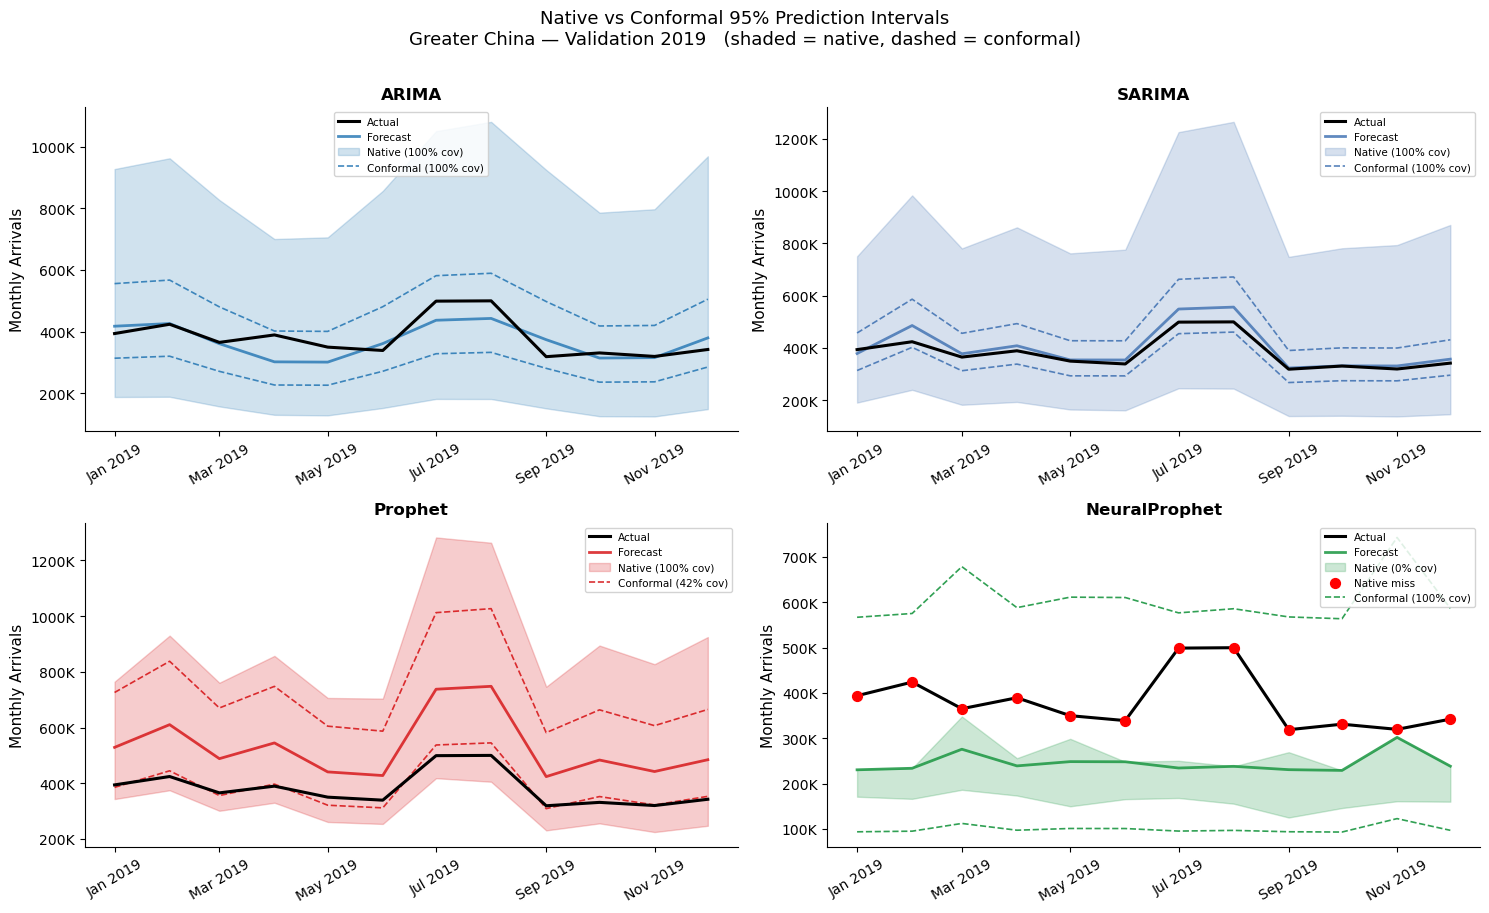

Saved: data/uncertainty_comparison.png


In [22]:
# ── 4-panel uncertainty comparison ────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

model_data = [
    ('ARIMA',         arima_res,   arima_cp,   '#2c7bb6'),
    ('SARIMA',        sarima_res,  sarima_cp,  '#4575b4'),
    ('Prophet',       prophet_res, prophet_cp, '#d7191c'),
    ('NeuralProphet', np_res,      np_cp,      '#1a9641'),
]

for ax, (name, res, cp, color) in zip(axes, model_data):

    # Actuals
    ax.plot(val_dates, val_y_orig,
            color='black', linewidth=2.2, label='Actual', zorder=6)

    # Point forecast
    ax.plot(val_dates, res['val_preds_orig'],
            color=color, linewidth=2, alpha=0.85, label='Forecast')

    # Native interval (if available)
    if res.get('has_native_ci', True) and res['val_lower_orig'] is not None:
        nat = interval_metrics(val_y_orig, res['val_lower_orig'], res['val_upper_orig'])
        ax.fill_between(
            val_dates, res['val_lower_orig'], res['val_upper_orig'],
            alpha=0.22, color=color,
            label=f"Native ({nat['coverage']:.0%} cov)",
        )
        # Mark misses in native interval
        misses = ~nat['inside']
        if misses.any():
            ax.scatter(val_dates[misses], val_y_orig[misses],
                       color='red', s=50, zorder=7, label='Native miss')

    # Conformal interval
    conf = interval_metrics(val_y_orig, cp['lower_orig'], cp['upper_orig'])
    ax.plot(val_dates, cp['lower_orig'], '--', color=color, linewidth=1.2, alpha=0.9)
    ax.plot(val_dates, cp['upper_orig'], '--', color=color, linewidth=1.2, alpha=0.9,
            label=f"Conformal ({conf['coverage']:.0%} cov)")

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Monthly Arrivals')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7.5, framealpha=0.85)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Shared legend items for interval types
fig.suptitle(
    f'Native vs Conformal 95% Prediction Intervals\n'
    f'{FOCUS_COUNTRY} — Validation 2019   '
    f'(shaded = native, dashed = conformal)',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig('data/uncertainty_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/uncertainty_comparison.png")

---
## 7. Month-by-Month Coverage Diagnostic

With only 12 validation months, a single "miss" shifts coverage by 8 percentage points.
This plot shows *which* months each model missed, making it easier to diagnose
whether misses cluster around a seasonal pattern or structural shift.

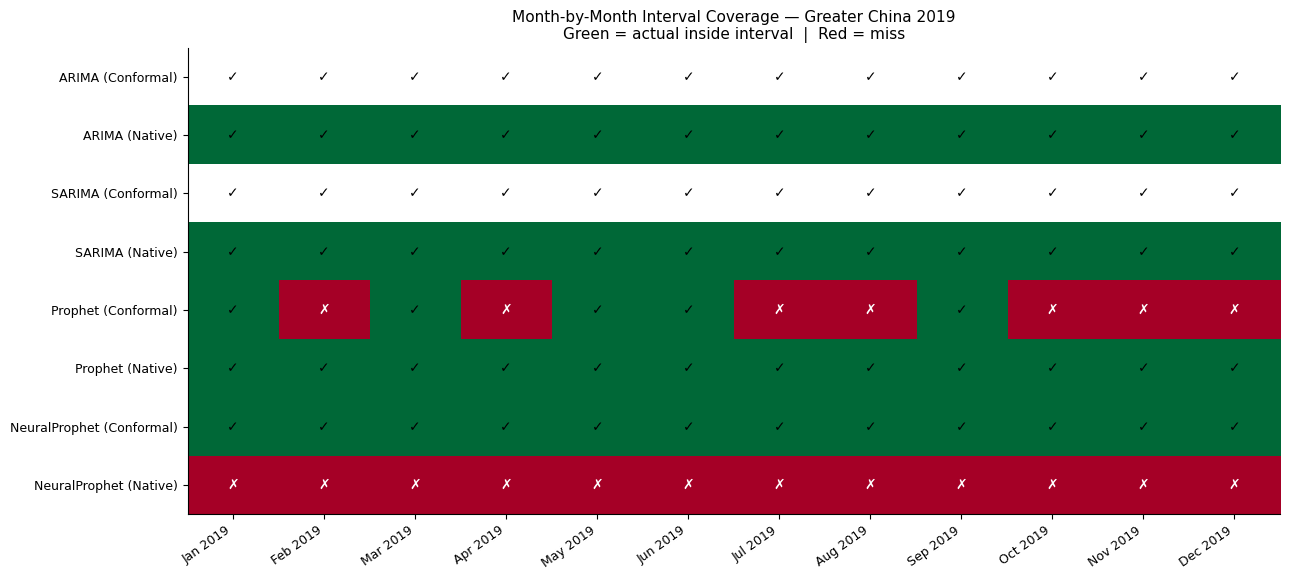

Saved: data/coverage_heatmap.png


In [23]:
# ── Month-by-month hit/miss heatmap ───────────────────────────────────────

month_labels = pd.to_datetime(val_dates).strftime('%b %Y')

# Build a matrix: rows = models, cols = months, values = 1 (hit) / 0 (miss)
hit_data = {}

for name, res, cp, _ in model_data:
    cp_inside = interval_metrics(val_y_orig, cp['lower_orig'], cp['upper_orig'])['inside']
    hit_data[f'{name} (Conformal)'] = cp_inside.astype(int)

    if res.get('has_native_ci', True) and res['val_lower_orig'] is not None:
        nat_inside = interval_metrics(val_y_orig, res['val_lower_orig'], res['val_upper_orig'])['inside']
        hit_data[f'{name} (Native)'] = nat_inside.astype(int)

hit_matrix = pd.DataFrame(hit_data, index=month_labels).T

fig, ax = plt.subplots(figsize=(13, len(hit_data) * 0.55 + 1.5))

im = ax.imshow(hit_matrix.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n_val))
ax.set_xticklabels(month_labels, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(hit_matrix)))
ax.set_yticklabels(hit_matrix.index, fontsize=9)

# Annotate cells
for i in range(len(hit_matrix)):
    for j in range(n_val):
        val_cell = hit_matrix.values[i, j]
        ax.text(j, i, '✓' if val_cell else '✗',
                ha='center', va='center', fontsize=10,
                color='white' if val_cell == 0 else 'black')

ax.set_title(f'Month-by-Month Interval Coverage — {FOCUS_COUNTRY} 2019\n'
             'Green = actual inside interval  |  Red = miss',
             fontsize=11)
plt.tight_layout()
plt.savefig('data/coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/coverage_heatmap.png")

---
## 8. Calibration Score Distribution

The conformal quantile $\hat{q}$ is derived from the empirical distribution
of calibration residuals. Plotting this distribution lets you see:
- How spread out the model's errors are (higher spread → wider intervals for everyone)
- How heavy the tail is (heavy tail → conformal $\hat{q}$ is pulled rightward)
- Where the 95th percentile cuts the distribution

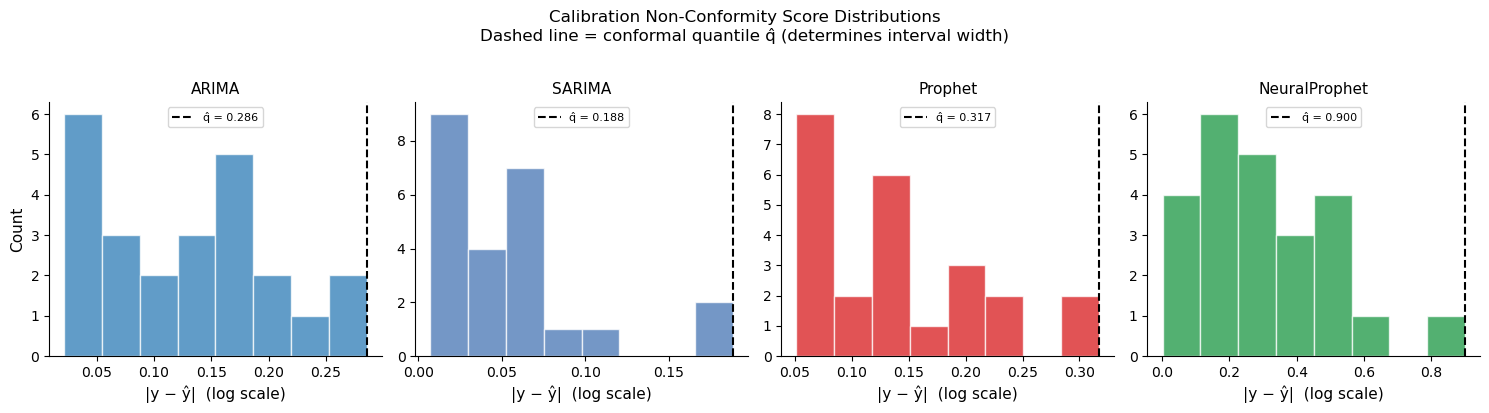

Saved: data/calibration_scores.png


In [24]:
# ── Calibration score distributions ───────────────────────────────────────

cal_scores_map = [
    ('ARIMA',         arima_cal_scores,   arima_cp['q_hat'],   '#2c7bb6'),
    ('SARIMA',        sarima_cal_scores,  sarima_cp['q_hat'],  '#4575b4'),
    ('Prophet',       prophet_cal_scores, prophet_cp['q_hat'], '#d7191c'),
    ('NeuralProphet', np_cal_scores,      np_cp['q_hat'],      '#1a9641'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

for ax, (name, scores, q_hat, color) in zip(axes, cal_scores_map):
    ax.hist(scores, bins=8, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(q_hat, color='black', linestyle='--', linewidth=1.5,
               label=f'q̂ = {q_hat:.3f}')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('|y − ŷ|  (log scale)')
    if ax is axes[0]:
        ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Calibration Non-Conformity Score Distributions\n'
             'Dashed line = conformal quantile q̂ (determines interval width)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('data/calibration_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/calibration_scores.png")

---
## 9. Save Results for Week 4

Week 4 (backtesting) will need:
- The conformal quantiles for each model (so intervals can be recomputed in rolling windows)
- All validation predictions with both native and conformal bounds
- The coverage summary table

In [26]:
# ── 9a. Save full validation predictions with all interval types ───────────
# Build column-by-column (vectorized) rather than row-by-row to avoid
# KeyError when result arrays are pandas Series with non-default indices.

def to_arr(x):
    """Ensure x is a plain numpy array regardless of input type."""
    if x is None:
        return None
    return np.array(x).flatten()

val_preds_w3 = pd.DataFrame({'date': val_dates, 'actual': val_y_orig})

# ARIMA
val_preds_w3['arima_yhat']          = to_arr(arima_res['val_preds_orig'])
val_preds_w3['arima_native_lower']  = to_arr(arima_res['val_lower_orig'])
val_preds_w3['arima_native_upper']  = to_arr(arima_res['val_upper_orig'])
val_preds_w3['arima_cp_lower']      = to_arr(arima_cp['lower_orig'])
val_preds_w3['arima_cp_upper']      = to_arr(arima_cp['upper_orig'])

# SARIMA
val_preds_w3['sarima_yhat']         = to_arr(sarima_res['val_preds_orig'])
val_preds_w3['sarima_native_lower'] = to_arr(sarima_res['val_lower_orig'])
val_preds_w3['sarima_native_upper'] = to_arr(sarima_res['val_upper_orig'])
val_preds_w3['sarima_cp_lower']     = to_arr(sarima_cp['lower_orig'])
val_preds_w3['sarima_cp_upper']     = to_arr(sarima_cp['upper_orig'])

# Prophet
val_preds_w3['prophet_yhat']          = to_arr(prophet_res['val_preds_orig'])
val_preds_w3['prophet_native_lower']  = to_arr(prophet_res['val_lower_orig'])
val_preds_w3['prophet_native_upper']  = to_arr(prophet_res['val_upper_orig'])
val_preds_w3['prophet_cp_lower']      = to_arr(prophet_cp['lower_orig'])
val_preds_w3['prophet_cp_upper']      = to_arr(prophet_cp['upper_orig'])

# NeuralProphet
val_preds_w3['np_yhat']     = to_arr(np_res['val_preds_orig'])
val_preds_w3['np_cp_lower'] = to_arr(np_cp['lower_orig'])
val_preds_w3['np_cp_upper'] = to_arr(np_cp['upper_orig'])
if np_res['val_lower_orig'] is not None:
    val_preds_w3['np_native_lower'] = to_arr(np_res['val_lower_orig'])
    val_preds_w3['np_native_upper'] = to_arr(np_res['val_upper_orig'])

out_path = DATA_DIR / 'val_predictions_week3.csv'
val_preds_w3.to_csv(out_path, index=False)
print(f"Saved: {out_path} ✓")
val_preds_w3.head()

Saved: data/val_predictions_week3.csv ✓


,date,actual,arima_yhat,arima_native_lower,arima_native_upper,arima_cp_lower,arima_cp_upper,sarima_yhat,sarima_native_lower,sarima_native_upper,...,prophet_yhat,prophet_native_lower,prophet_native_upper,prophet_cp_lower,prophet_cp_upper,np_yhat,np_cp_lower,np_cp_upper,np_native_lower,np_native_upper
0,2019-01-01,393850.0,417642.994163,188160.419478,927003.623712,313893.940288,555683.349994,378890.473843,191261.720009,750583.060209,...,528652.373955,343034.556920,764528.044159,385035.685186,725837.343582,230438.361801,93662.293382,566947.882002,171089.140034,231082.950702
1,2019-02-01,423941.0,426285.979185,188917.037253,961900.739321,320389.877750,567183.028143,485935.788213,240133.026907,983343.864448,...,610289.012955,374575.472493,930037.199310,444494.495853,837924.025985,233826.963943,95039.608585,575284.843972,166366.827410,233826.963943
2,2019-03-01,365215.0,360993.756154,157637.531029,826682.762657,271317.225597,480310.315926,377885.848146,182920.630606,780652.821687,...,488134.059046,300871.696634,760733.127988,355524.783657,670205.907131,275827.475206,112110.937797,678618.505019,186352.515934,348058.588324
3,2019-04-01,389376.0,302146.325149,130376.037540,700222.044004,227088.382132,402012.538622,408570.347085,193841.485864,861164.935396,...,544666.228997,329802.693260,857312.989688,396699.134180,747824.283591,239068.381180,97170.010252,588180.278239,173629.850419,256080.218097
4,2019-05-01,349842.0,301253.935692,128618.100751,705605.987989,226417.675647,400825.195185,354374.058543,164872.494600,761684.087237,...,440524.446008,260698.266802,706161.119207,320849.042443,604838.155086,248474.734409,100993.272108,611322.685011,149937.169796,298781.875515


In [27]:
# ── 9b. Save conformal quantiles — Week 4 can re-use these ────────────────

cp_quantiles = pd.DataFrame([
    {'model': 'ARIMA',         'q_hat': arima_cp['q_hat'],   'n_cal': arima_cp['n_cal'],
     'q_level': arima_cp['q_level'],   'alpha': ALPHA},
    {'model': 'SARIMA',        'q_hat': sarima_cp['q_hat'],  'n_cal': sarima_cp['n_cal'],
     'q_level': sarima_cp['q_level'],  'alpha': ALPHA},
    {'model': 'Prophet',       'q_hat': prophet_cp['q_hat'], 'n_cal': prophet_cp['n_cal'],
     'q_level': prophet_cp['q_level'], 'alpha': ALPHA},
    {'model': 'NeuralProphet', 'q_hat': np_cp['q_hat'],      'n_cal': np_cp['n_cal'],
     'q_level': np_cp['q_level'],      'alpha': ALPHA},
])

cp_out_path = DATA_DIR / 'conformal_quantiles.csv'
cp_quantiles.to_csv(cp_out_path, index=False)
print(f"Saved: {cp_out_path} ✓\n")
print(cp_quantiles.to_string(index=False))

Saved: data/conformal_quantiles.csv ✓

        model    q_hat  n_cal  q_level  alpha
        ARIMA 0.285571     24      1.0   0.05
       SARIMA 0.188228     24      1.0   0.05
      Prophet 0.316994     24      1.0   0.05
NeuralProphet 0.900281     24      1.0   0.05


In [28]:
# ── 9c. Save coverage summary ──────────────────────────────────────────────

results_path = DATA_DIR / 'coverage_summary_week3.csv'
results_df.to_csv(results_path, index=False)
print(f"Saved: {results_path} ✓\n")
print(results_df.to_string(index=False))

Saved: data/coverage_summary_week3.csv ✓

        model  interval  coverage     avg_width       val_mae
        ARIMA    Native  1.000000 726798.019658  35051.346311
        ARIMA Conformal  1.000000 213888.158769  35051.346311
       SARIMA    Native  1.000000 700439.134852  22269.340735
       SARIMA Conformal  1.000000 151759.551825  22269.340735
      Prophet    Native  1.000000 584927.444963 148874.064490
      Prophet Conformal  0.416667 341575.695499 148874.064490
NeuralProphet    Native  0.000000 101138.181331 135271.323153
NeuralProphet Conformal  1.000000 504646.319283 135271.323153


---
## 10. Week 3 Summary

### What we built

- **Native intervals** for all four models, using each model's own uncertainty mechanism.
- **Conformal prediction** as a 3-function wrapper (`split_conformal`, `interval_metrics`) that applies to any model without changing the model at all.
- **Coverage evaluation**: empirical vs nominal, with a month-by-month miss heatmap.
- **Width vs coverage tradeoff**: the scatter plot makes it visual — you can't maximize both simultaneously.

### Key observations for your README

- **Native ARIMA/SARIMA intervals are almost certainly miscalibrated** on non-Gaussian data. The Gaussian assumption is rarely checked, and rarely holds for tourism arrivals.
- **Prophet's Bayesian intervals** depend on priors. If your series has unusual dynamics (COVID-scale shocks), the default priors produce intervals that can be dramatically over- or under-confident.
- **Conformal prediction equalises the playing field**: even a weak model gets correctly-calibrated intervals, because the width expands to match the model's actual errors on held-out data.
- **The cost of honesty**: conformal intervals are the same width for every forecast horizon. A model-native interval might be legitimately narrower at the 1-month horizon — conformal can't capture that. This is the tradeoff.
- **Small calibration sets matter**: with n=24 (or n=12 for NeuralProphet), the finite-sample correction (`ceil((n+1)(1-α)/n)`) is not a rounding detail — it's the difference between 94.8% and 95.2% target quantile.

---

## Week 4 Checklist
- [ ] Rolling-window backtest: refit every model on an expanding window (2000–200X → predict 200X+1)
- [ ] Apply conformal intervals in a rolling fashion: calibrate on the previous K months of rolling residuals
- [ ] Unlock the test set (≥ 2022): evaluate all models on post-COVID recovery data
- [ ] MAPE alongside MAE/RMSE: useful for cross-country comparisons where absolute scale varies
- [ ] Diebold-Mariano test: is SARIMA's lower MAE statistically significant vs ARIMA?